# C1 Relevant Parameters — fixed depth policies

Depth sweep on SynthACticBench C1 with depths 3, 6, 9, 12, 15, and 20.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "01_initial":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/c1_relevant_parameters/depth_policies/01_initial")
OUTPUT_DIRECTORY = HERE / "smac_output"
DEPTHS = (3, 6, 9, 12, 15, 20)
POLICIES = tuple(f"fixed_depth_{depth}" for depth in DEPTHS)
SEEDS = tuple(range(5))
N_TRIALS = 1000
N_INSTANCES = 10
PROBLEM_SEED = 52
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{depth}": f"depth = {depth}" for depth in DEPTHS}
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "C5")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    expected_depth = int(policy.rsplit("_", 1)[1])
    for result in runs.values():
        assert result["problem"] == "C1-RelevantParameters"
        assert result["dimension"] == 10
        assert result["num_quadratic"] == 3
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["deterministic"] is False
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["max_depth"] == expected_depth
        assert result["min_samples_leaf"] == 3
        assert result["min_samples_split"] == 3
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
print(f"Loaded {sum(map(len, results.values()))}/30 validated trajectories.")

Loaded 30/30 validated trajectories.


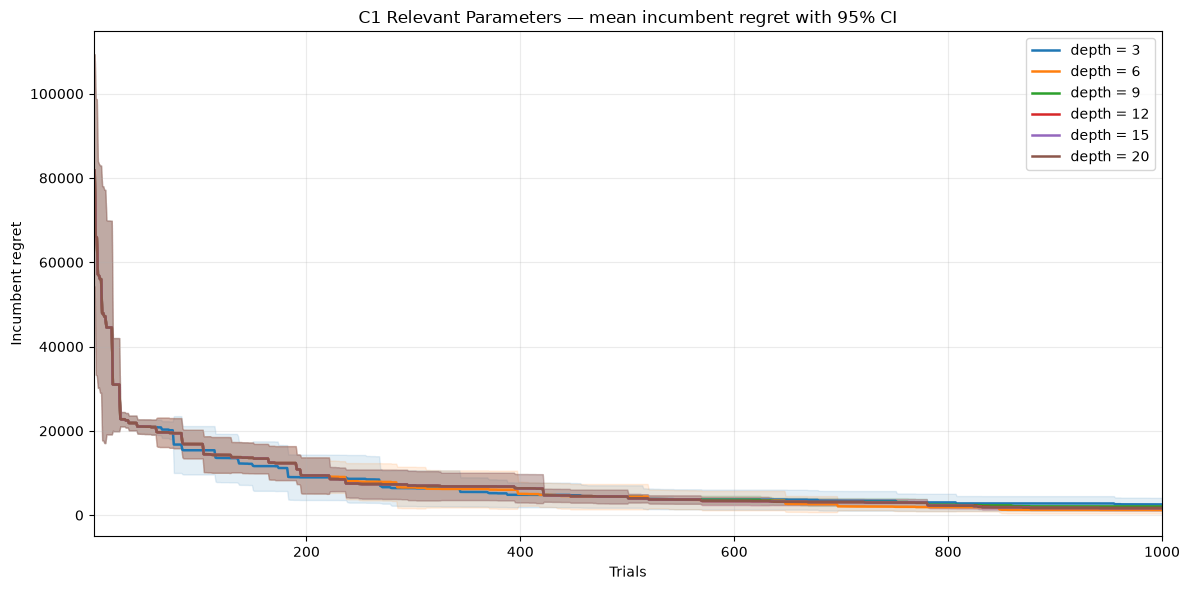

In [3]:
rows = [{"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret} for policy, runs in results.items() for seed, result in runs.items() for iteration, regret in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=1.8)
    ax.fill_between(data.iteration, data["mean"] - data.ci95, data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="C1 Relevant Parameters — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS))
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

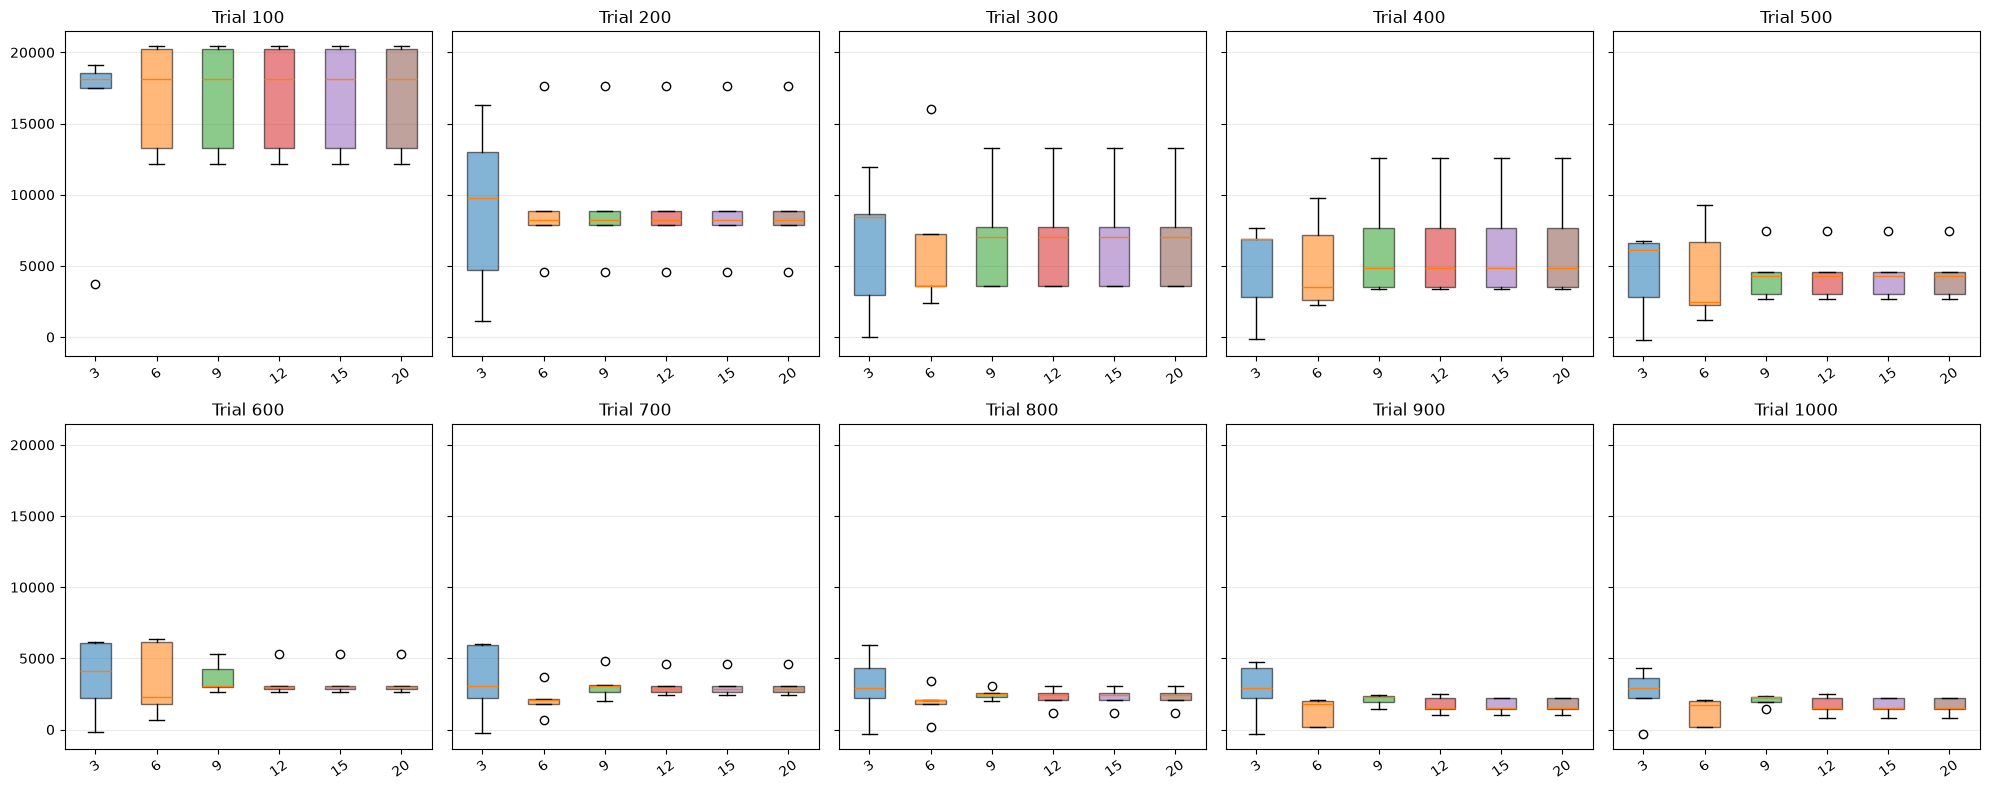

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(depth) for depth in DEPTHS])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x", rotation=35); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()

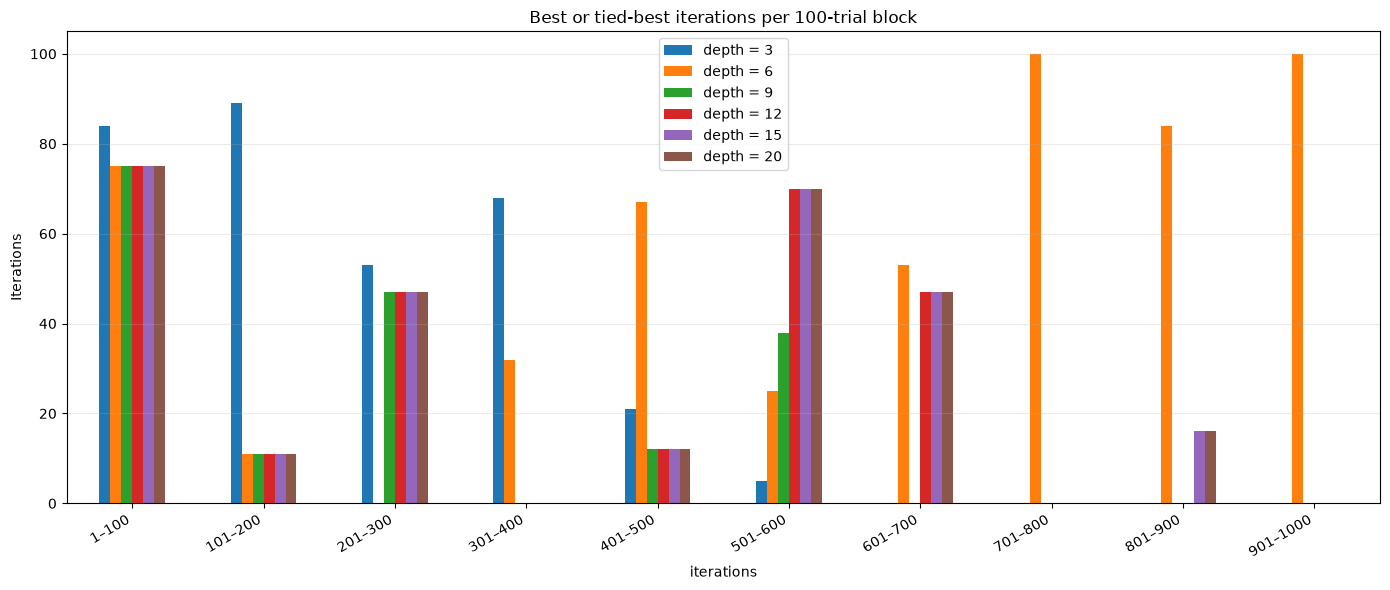

,iterations,superior policy,depth = 3,depth = 6,depth = 9,depth = 12,depth = 15,depth = 20
0,1–100,depth = 3,84,75,75,75,75,75
1,101–200,depth = 3,89,11,11,11,11,11
2,201–300,depth = 3,53,0,47,47,47,47
3,301–400,depth = 3,68,32,0,0,0,0
4,401–500,depth = 6,21,67,12,12,12,12
5,501–600,"depth = 12, depth = 15, depth = 20",5,25,38,70,70,70
6,601–700,depth = 6,0,53,0,47,47,47
7,701–800,depth = 6,0,100,0,0,0,0
8,801–900,depth = 6,0,84,0,0,16,16
9,901–1000,depth = 6,0,100,0,0,0,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum(); maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES}); block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105)); ax.grid(axis="y", alpha=.25); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(block_superiority)

In [6]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                                      \
                   mean          std       median          min          max   
policy                                                                        
depth = 6   1228.409155   961.579768  1723.727385   167.947924  2069.274172   
depth = 15  1646.494284   594.519589  1484.418683   834.459801  2237.837208   
depth = 20  1646.494284   594.519589  1484.418683   834.459801  2237.837208   
depth = 12  1699.938737   667.458101  1484.418683   834.459801  2495.743100   
depth = 9   2068.355074   397.202003  2264.255982  1420.194119  2386.312678   
depth = 3   2553.373332  1776.300086  2904.294633  -298.597725  4312.324577   

           mean_incumbent_regret                                         \
                            mean          std       median          min   
policy                                                                    
depth = 6            7057.794971  2157.743242  6111.582434  4727.501492   
depth = 15           7306.606052  1205.814314  6513.086618  6345.104904   
depth = 20           7306.606052  1205.814314  6513.086618  6345.104904   
depth = 12           7318.333722  1195.886053  6528.508791  6345.104904   
depth = 9            7416.763357  1416.726860  6542.247593  6222.628567   
depth = 3            7324.040491  2495.146944  8756.848112  3291.024980   

                          
                     max  
policy                    
depth = 6   10119.018867  
depth = 15   8921.128561  
depth = 20   8921.128561  
depth = 12   8921.128561  
depth = 9    9263.768653  
depth = 3    9230.316042

,policy,seed,final_regret,mean_incumbent_regret
9,depth = 6,0,167.947924,4727.501492
14,depth = 9,0,1420.194119,6542.247593
19,depth = 12,0,1484.418683,6513.086618
24,depth = 15,0,1484.418683,6513.086618
29,depth = 20,0,1484.418683,6513.086618
4,depth = 3,0,3629.695133,8756.848112
8,depth = 6,1,1723.727385,5960.535039
13,depth = 9,1,1958.768742,6222.628567
3,depth = 3,1,2219.150044,6506.913926
18,depth = 12,1,2237.837208,6345.104904


In [7]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(checkpoint_table)

mean          std           min  \
iteration policy                                                    
100       fixed_depth_12  16860.558294  3875.030707  12191.376264   
          fixed_depth_15  16860.558294  3875.030707  12191.376264   
          fixed_depth_20  16860.558294  3875.030707  12191.376264   
          fixed_depth_3   15396.277127  6552.946325   3722.544935   
          fixed_depth_6   16860.558294  3875.030707  12191.376264   
          fixed_depth_9   16860.558294  3875.030707  12191.376264   
200       fixed_depth_12   9419.610680  4895.326307   4536.511209   
          fixed_depth_15   9419.610680  4895.326307   4536.511209   
          fixed_depth_20   9419.610680  4895.326307   4536.511209   
          fixed_depth_3    8975.971445  6138.946995   1105.904925   
          fixed_depth_6    9419.610680  4895.326307   4536.511209   
          fixed_depth_9    9419.610680  4895.326307   4536.511209   
300       fixed_depth_12   7041.479490  3963.888654   3592.887315   
          fixed_depth_15   7041.479490  3963.888654   3592.887315   
          fixed_depth_20   7041.479490  3963.888654   3592.887315   
          fixed_depth_3    6411.169784  4834.905905    -30.237989   
          fixed_depth_6    6572.758230  5596.218312   2381.920649   
          fixed_depth_9    7041.479490  3963.888654   3592.887315   
400       fixed_depth_12   6383.414895  3847.168167   3381.421755   
          fixed_depth_15   6383.414895  3847.168167   3381.421755   
          fixed_depth_20   6383.414895  3847.168167   3381.421755   
          fixed_depth_3    4819.503870  3354.856835   -135.875804   
          fixed_depth_6    5064.309399  3268.129586   2276.282833   
          fixed_depth_9    6383.414895  3847.168167   3381.421755   
500       fixed_depth_12   4397.063269  1884.616031   2662.751762   
          fixed_depth_15   4397.063269  1884.616031   2662.751762   
          fixed_depth_20   4397.063269  1884.616031   2662.751762   
          fixed_depth_3    4413.724732  3040.207040   -186.134179   
          fixed_depth_6    4388.211533  3440.589782   1202.420240   
          fixed_depth_9    4397.063269  1884.616031   2662.751762   
600       fixed_depth_12   3361.680487  1094.569695   2662.751762   
          fixed_depth_15   3361.680487  1094.569695   2662.751762   
          fixed_depth_20   3361.680487  1094.569695   2662.751762   
          fixed_depth_3    3685.702310  2706.738784   -186.134179   
          fixed_depth_6    3453.848670  2615.644640    696.343075   
          fixed_depth_9    3649.673273  1113.892403   2662.751762   
700       fixed_depth_12   3113.618308   867.439114   2452.138845   
          fixed_depth_15   3113.618308   867.439114   2452.138845   
          fixed_depth_20   3113.618308   867.439114   2452.138845   
          fixed_depth_3    3408.064178  2656.600029   -252.511658   
          fixed_depth_6    2083.863979  1083.642663    696.343075   
          fixed_depth_9    3123.942045  1041.673468   2033.835480   
800       fixed_depth_12   2259.477377   700.462673   1171.292566   
          fixed_depth_15   2259.477377   700.462673   1171.292566   
          fixed_depth_20   2259.477377   700.462673   1171.292566   
          fixed_depth_3    3020.605686  2332.909501   -298.597725   
          fixed_depth_6    1909.903667  1156.195551    196.928595   
          fixed_depth_9    2488.975596   394.802826   1987.749413   
900       fixed_depth_12   1739.078448   607.020108   1030.158357   
          fixed_depth_15   1685.633995   530.712859   1030.158357   
          fixed_depth_20   1685.633995   530.712859   1030.158357   
          fixed_depth_3    2769.914009  1993.078007   -298.597725   
          fixed_depth_6    1238.826361   968.544176    167.947924   
          fixed_depth_9    2085.442714   411.883573   1420.194119   
1000      fixed_depth_12   1699.938737   667.458101    834.459801   
          fixed_depth_15   1646.494284   594.519589    834.459801   
          fixed_depth_20   1646.